In [25]:
# K-means Clustering 실습1

In [26]:
# 2차원 좌표값을 산점도로 나타내고 클러스터링 해보시오
# 군집 개수는 임의로 설정

In [27]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv("./data/dots.csv")

In [29]:
df

,x,y
0,1,1
1,1,0
2,2,1
3,5,3
4,6,7
5,6,6
6,8,0
7,11,2
8,12,1
9,2,2


Text(42.25000000000001, 0.5, 'y')

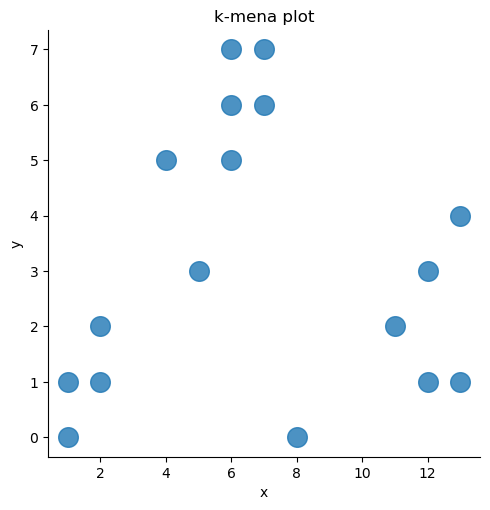

In [30]:
# 산점도 그리기

sns.lmplot(x='x', y='y', data=df, fit_reg=False, scatter_kws={"s":200})

# fit_reg=False 회귀직선 없이 산점도만 그림
# scatter_kws는 size를 조절

plt.title('k-mena plot')
plt.xlabel('x')
plt.ylabel('y')

In [31]:
# 적정 클러스터 갯수 구하기: 엘보우 메소드
# 엘보우를 찾아라!
# 오차제곰합(SSE)값이 inertia_에 저장되며 이 값을 이용하여 그래프 작성

In [32]:
!pip install threadpoolctl==3.1.0

C:\Users\dbwls\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dbwls\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dbwls\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dbwls\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

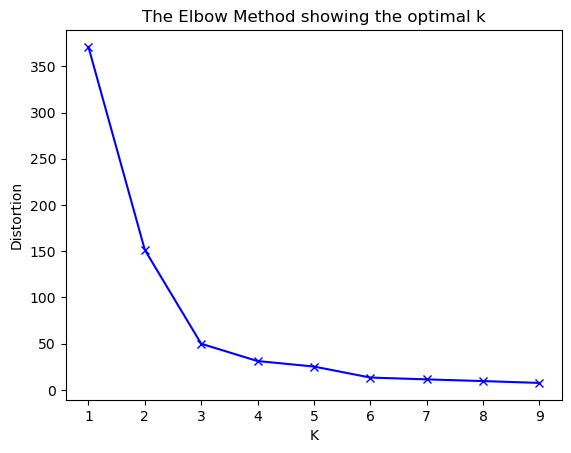

In [33]:
X = df.values # 인덱스를 제외한 값을 ndarray로 추출
inertia_arr = []
K = range(1,10)
for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=0).fit(X) #모델 적합
    inertia = kmeanModel.inertia_
    inertia_arr.append(inertia)

# Plot the elbow
plt.plot(K, inertia_arr, 'bx-')
plt.xlabel('K')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.show()

In [34]:
# 적정 클러스터 수 계산
# k=3으로 클러스터링

# 최적 k 개수로 클러스터링 수행
kmeans = KMeans(n_clusters = 3)
kmeans.fit(X)

C:\Users\dbwls\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3)

In [35]:
kmeans.labels_ # 클러스터 결과 확인

array([2, 2, 2, 0, 0, 0, 1, 1, 1, 2, 1, 0, 0, 1, 1, 0, 0])

In [36]:
df['cluster_id'] = kmeans.labels_

In [37]:
df

,x,y,cluster_id
0,1,1,2
1,1,0,2
2,2,1,2
3,5,3,0
4,6,7,0
5,6,6,0
6,8,0,1
7,11,2,1
8,12,1,1
9,2,2,2


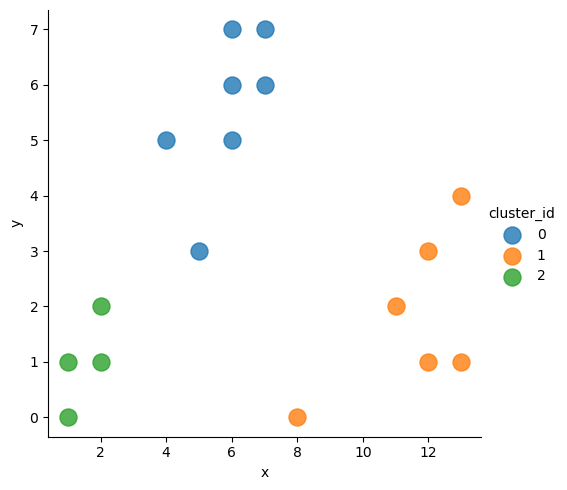

In [38]:
# 클러스터링 시각화
sns.lmplot(x='x', y='y', data=df, fit_reg=False, scatter_kws={"s":150}, hue='cluster_id')

In [39]:
"

SyntaxError: unterminated string literal (detected at line 1) (1845220801.py, line 1)